### OBJECTIVE 

This objective this program is to analyze a high- dimensional socio- economic and helath dataset by applying principal component analysis (PCA) to reduce dimensionality and extract the most significant underlying factors


These principal components are then used as input features in logistic regression/neural network model to predict the likelihood of child malnutrinuition 

Approach aims to:

Reduce redundancy and multicollinearity among various improve computational eficeincy Identify latent structures influencing malnutrition Based a build predictive model for classification of malnutrition risk

This dataset is survey-style dataset designed to resemble large-scale Indian household surveys such as the Nation Faily Health survey.
It contains 100,000 observations, where each row represents a household or child with multi socio-economic , health, and environmental attributes.

The variables are structured around key development dimensions such as:

Income

Food security

Health status

Education

Gender factors

Sanitation

Infrastructure

Climate risk


These features collectively capture the multidimensional causes of child malnutrition.

The dataset includes both:

Continuous variables (e.g., income, dietary diversity)

Categorical/binary indicators (e.g., immunization status, access to clean water)


A target variable, Malnutrition_Risk, is included as a binary outcome indicating whether a child is at high or low risk of malnutrition.

Although the data is synthetically generated, it follows realistic statistical distributions, making it suitable for applying techniques like PCA and logistic regression for analysis and modeling.

In [1]:
import numpy as np

In [2]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
from tensorflow import keras
from keras import layers

In [5]:
df = pd.read_csv("sdg_malnutrition_dataset.csv")

In [6]:
df.shape

(100000, 41)

In [7]:
# Poverty_Status 
# Social_Protection_Access 
# Dietary_Diversity_Score 
# Meal_Frequency
# Immunization_Status 
# Slum_Residence 
# Population_Density 
# Climate_Shock_Exposure 
# Crop_Failure_Incidence 
# Malnutrition_Risk 

### Categorical dataset

In [8]:
df_categorical = df[['Poverty_Status','Social_Protection_Access','Dietary_Diversity_Score','Meal_Frequency','Immunization_Status','Slum_Residence','Climate_Shock_Exposure','Crop_Failure_Incidence','Disease_Incidence','Mother_Education_Level']]

In [9]:
df_categorical

,Poverty_Status,Social_Protection_Access,Dietary_Diversity_Score,Meal_Frequency,Immunization_Status,Slum_Residence,Climate_Shock_Exposure,Crop_Failure_Incidence,Disease_Incidence,Mother_Education_Level
0,0,1,8,1,0,0,0,0,3,10
1,0,1,5,2,1,0,0,0,2,8
2,0,1,7,2,1,1,1,1,1,0
3,1,1,5,4,1,0,1,0,3,3
4,0,0,9,4,1,1,0,0,9,12
...,...,...,...,...,...,...,...,...,...,...
99995,0,1,7,1,1,0,0,0,1,6
99996,0,0,3,3,1,0,0,0,0,1
99997,0,1,2,2,1,0,0,1,0,3
99998,0,1,9,3,1,1,0,0,2,11


In [10]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

min_max = MinMaxScaler()

scaled_data = min_max.fit_transform(df_categorical)

df_categorical_scaled = pd.DataFrame(scaled_data, columns=df_categorical.columns)

df_categorical_scaled


,Poverty_Status,Social_Protection_Access,Dietary_Diversity_Score,Meal_Frequency,Immunization_Status,Slum_Residence,Climate_Shock_Exposure,Crop_Failure_Incidence,Disease_Incidence,Mother_Education_Level
0,0.0,1.0,0.875,0.000000,0.0,0.0,0.0,0.0,0.3,0.666667
1,0.0,1.0,0.500,0.333333,1.0,0.0,0.0,0.0,0.2,0.533333
2,0.0,1.0,0.750,0.333333,1.0,1.0,1.0,1.0,0.1,0.000000
3,1.0,1.0,0.500,1.000000,1.0,0.0,1.0,0.0,0.3,0.200000
4,0.0,0.0,1.000,1.000000,1.0,1.0,0.0,0.0,0.9,0.800000
...,...,...,...,...,...,...,...,...,...,...
99995,0.0,1.0,0.750,0.000000,1.0,0.0,0.0,0.0,0.1,0.400000
99996,0.0,0.0,0.250,0.666667,1.0,0.0,0.0,0.0,0.0,0.066667
99997,0.0,1.0,0.125,0.333333,1.0,0.0,0.0,1.0,0.0,0.200000
99998,0.0,1.0,1.000,0.666667,1.0,1.0,0.0,0.0,0.2,0.733333


### Numerical dataset

In [11]:

df_numerical = df.drop(columns=[ 'Poverty_Status', 'Social_Protection_Access', 'Dietary_Diversity_Score',  'Meal_Frequency', 'Immunization_Status', 'Slum_Residence', 'Climate_Shock_Exposure', 'Crop_Failure_Incidence','Disease_Incidence','Mother_Education_Level'])




In [12]:
df_numerical = df_numerical.iloc[:,:-1]

In [13]:
df_numerical

,Household_Income,Food_Expenditure_Ratio,Food_Availability,Child_Feeding_Practices,Child_Health_Status,Maternal_Health_Status,Nutrition_Awareness,School_Attendance,Women_Decision_Making_Index,Early_Marriage_Indicator,...,Road_Accessibility,Market_Access,Income_Inequality_Index,Social_Inclusion_Index,Access_To_Services_Equity,Housing_Condition,Population_Density,Food_Wastage_Level,Food_Storage_Practices,Weather_Variability
0,28236.114017,0.663549,0.683364,0.258585,0.791974,0.068376,0.889100,0.994615,0.728039,0,...,0.711343,0.578383,0.252888,0.308682,0.474607,0.940448,13379,0.860530,0.335483,0.005176
1,20555.171637,0.456270,0.831084,0.944793,0.665151,0.122412,0.692703,0.762831,0.705786,1,...,0.759907,0.505991,0.498352,0.956154,0.276406,0.732535,14585,0.165408,0.230523,0.408611
2,30450.091226,0.493708,0.825048,0.655804,0.364330,0.082325,0.300435,0.802691,0.035329,1,...,0.072762,0.732305,0.599073,0.395706,0.539590,0.421672,4186,0.038422,0.199440,0.122318
3,47170.073204,0.592818,0.514674,0.768238,0.327269,0.061037,0.474227,0.855981,0.201680,0,...,0.125492,0.212468,0.342341,0.644917,0.373299,0.482478,14713,0.504149,0.906650,0.808787
4,19592.915242,0.469154,0.772103,0.196116,0.162214,0.727593,0.970990,0.668662,0.676204,0,...,0.825980,0.482658,0.419102,0.336335,0.093860,0.489095,14006,0.435767,0.782797,0.251836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,19680.577855,0.680733,0.941333,0.991463,0.180564,0.961574,0.061686,0.935462,0.280477,0,...,0.044056,0.105557,0.452060,0.378234,0.450483,0.275159,309,0.068268,0.458044,0.773887
99996,16566.058748,0.443367,0.734824,0.805783,0.964006,0.056540,0.158625,0.781916,0.161603,0,...,0.770307,0.649547,0.511767,0.177112,0.610942,0.694190,2524,0.482350,0.503878,0.729106
99997,27027.024158,0.588332,0.974270,0.711537,0.826379,0.220261,0.904123,0.923289,0.937264,0,...,0.553686,0.215676,0.375126,0.668833,0.116863,0.088106,7821,0.388692,0.555223,0.283541
99998,19820.145811,0.617613,0.638520,0.835691,0.406573,0.289636,0.446961,0.810465,0.206096,0,...,0.999041,0.238627,0.398265,0.609690,0.341981,0.493732,12876,0.660536,0.908802,0.805022


In [14]:
scaler = StandardScaler()


df_numerical_scaled = scaler.fit_transform(df_numerical)

In [15]:
df_numerical_scaled = pd.DataFrame(df_numerical_scaled, columns=df_numerical.columns)

In [16]:
df_numerical_scaled

,Household_Income,Food_Expenditure_Ratio,Food_Availability,Child_Feeding_Practices,Child_Health_Status,Maternal_Health_Status,Nutrition_Awareness,School_Attendance,Women_Decision_Making_Index,Early_Marriage_Indicator,...,Road_Accessibility,Market_Access,Income_Inequality_Index,Social_Inclusion_Index,Access_To_Services_Equity,Housing_Condition,Population_Density,Food_Wastage_Level,Food_Storage_Practices,Weather_Variability
0,0.245130,1.417488,-0.462994,-0.839371,1.011879,-1.495799,1.344270,1.696526,0.792776,-0.650526,...,0.735037,0.269538,-1.274238,-0.660908,-0.085800,1.520519,0.576841,1.256798,-0.570317,-1.719049
1,-0.332286,-0.378586,0.563031,1.537982,0.572949,-1.308903,0.665996,0.090767,0.715607,1.537218,...,0.903351,0.018662,0.853076,1.584518,-0.771674,0.801875,0.786737,-1.152289,-0.933530,-0.319479
2,0.411566,-0.054191,0.521107,0.536786,-0.468177,-1.447550,-0.688739,0.366906,-1.609470,1.537218,...,-1.478178,0.802960,1.725970,-0.359112,0.139072,-0.272612,-1.023138,-1.592384,-1.041094,-1.312669
3,1.668492,0.804600,-1.634673,0.926310,-0.596445,-1.521181,-0.088532,0.736090,-1.032584,-0.650526,...,-1.295422,-0.998552,-0.498993,0.505152,-0.436375,-0.062439,0.809014,0.021686,1.406200,1.068784
4,-0.404624,-0.266947,0.153365,-1.055793,-1.167692,0.784254,1.627086,-0.561616,0.613017,-0.650526,...,1.132349,-0.062199,0.166251,-0.565008,-1.403375,-0.039569,0.685966,-0.215304,0.977609,-0.863353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,-0.398034,1.566382,1.328792,1.699669,-1.104181,1.593528,-1.513280,1.286723,-0.759323,-0.650526,...,-1.577668,-1.369056,0.451881,-0.419703,-0.169283,-0.779029,-1.697903,-1.488948,-0.146198,0.947710
99996,-0.632168,-0.490389,-0.105566,1.056383,1.607275,-1.536734,-1.178494,0.222983,-1.171565,-0.650526,...,0.939394,0.516160,0.969335,-1.117193,0.385985,0.669335,-1.312398,-0.053861,0.012412,0.792360
99997,0.154236,0.765730,1.557568,0.729871,1.130953,-0.970468,1.396152,1.202387,1.518346,-0.650526,...,0.188624,-0.987434,-0.214862,0.588090,-1.323771,-1.425574,-0.390491,-0.378452,0.190091,-0.753365
99998,-0.387542,1.019452,-0.774472,1.159999,-0.321974,-0.730520,-0.182698,0.420763,-1.017267,-0.650526,...,1.732149,-0.907897,-0.014327,0.382983,-0.544753,-0.023538,0.489297,0.563677,1.413645,1.055722


In [17]:
df_final = pd.concat([df_numerical_scaled, df_categorical_scaled], axis=1)

### Final dataset

In [18]:
df_final

,Household_Income,Food_Expenditure_Ratio,Food_Availability,Child_Feeding_Practices,Child_Health_Status,Maternal_Health_Status,Nutrition_Awareness,School_Attendance,Women_Decision_Making_Index,Early_Marriage_Indicator,...,Poverty_Status,Social_Protection_Access,Dietary_Diversity_Score,Meal_Frequency,Immunization_Status,Slum_Residence,Climate_Shock_Exposure,Crop_Failure_Incidence,Disease_Incidence,Mother_Education_Level
0,0.245130,1.417488,-0.462994,-0.839371,1.011879,-1.495799,1.344270,1.696526,0.792776,-0.650526,...,0.0,1.0,0.875,0.000000,0.0,0.0,0.0,0.0,0.3,0.666667
1,-0.332286,-0.378586,0.563031,1.537982,0.572949,-1.308903,0.665996,0.090767,0.715607,1.537218,...,0.0,1.0,0.500,0.333333,1.0,0.0,0.0,0.0,0.2,0.533333
2,0.411566,-0.054191,0.521107,0.536786,-0.468177,-1.447550,-0.688739,0.366906,-1.609470,1.537218,...,0.0,1.0,0.750,0.333333,1.0,1.0,1.0,1.0,0.1,0.000000
3,1.668492,0.804600,-1.634673,0.926310,-0.596445,-1.521181,-0.088532,0.736090,-1.032584,-0.650526,...,1.0,1.0,0.500,1.000000,1.0,0.0,1.0,0.0,0.3,0.200000
4,-0.404624,-0.266947,0.153365,-1.055793,-1.167692,0.784254,1.627086,-0.561616,0.613017,-0.650526,...,0.0,0.0,1.000,1.000000,1.0,1.0,0.0,0.0,0.9,0.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,-0.398034,1.566382,1.328792,1.699669,-1.104181,1.593528,-1.513280,1.286723,-0.759323,-0.650526,...,0.0,1.0,0.750,0.000000,1.0,0.0,0.0,0.0,0.1,0.400000
99996,-0.632168,-0.490389,-0.105566,1.056383,1.607275,-1.536734,-1.178494,0.222983,-1.171565,-0.650526,...,0.0,0.0,0.250,0.666667,1.0,0.0,0.0,0.0,0.0,0.066667
99997,0.154236,0.765730,1.557568,0.729871,1.130953,-0.970468,1.396152,1.202387,1.518346,-0.650526,...,0.0,1.0,0.125,0.333333,1.0,0.0,0.0,1.0,0.0,0.200000
99998,-0.387542,1.019452,-0.774472,1.159999,-0.321974,-0.730520,-0.182698,0.420763,-1.017267,-0.650526,...,0.0,1.0,1.000,0.666667,1.0,1.0,0.0,0.0,0.2,0.733333


In [19]:
y = df.iloc[:,-1]

## Test Train split

In [20]:
x_train, x_test, y_train, y_test = train_test_split(df_final,y, test_size=0.2, random_state= 12)

In [21]:
y_train.shape

(80000,)

### PCA


In [22]:
pca = PCA(n_components=10)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.fit_transform(x_test)

In [23]:
x_train_pca.shape

(80000, 10)

In [24]:
x_test_pca.shape

(20000, 10)

In [25]:
pca.explained_variance_

array([1.07460442, 1.06258182, 1.05361524, 1.04581075, 1.04091393,
       1.03624674, 1.02966616, 1.02625391, 1.02263128, 1.02072198])

In [26]:
np.sum(pca.explained_variance_ratio_)

np.float64(0.3312589058823919)

In [27]:
model = keras.Sequential([
    layers.Dense(units=32, activation='linear', input_shape=(10,)),
    
    layers.Dense(units=16, activation='relu'),
    
    layers.Dense(units=8, activation='relu'),
    
    layers.Dense(units=2, activation='sigmoid')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()



d:\Learning\Machine_learning\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,034 (4.04 KB)

 Trainable params: 1,034 (4.04 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = model.fit(x_train_pca, y_train, epochs=50, batch_size=50)

Epoch 1/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9965 - loss: 0.0245
Epoch 2/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9984 - loss: 0.0073
Epoch 3/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9984 - loss: 0.0064
Epoch 4/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9985 - loss: 0.0061
Epoch 5/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9986 - loss: 0.0058
Epoch 6/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9987 - loss: 0.0056
Epoch 7/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9987 - loss: 0.0056
Epoch 8/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9986 - loss: 0.0053
Epoch 9/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9987 - loss: 0.0053
Epoch 10/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9986 - loss: 0.0054
Epoch 11/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9988 - loss: 0.0052
Epoch 12/50
1600/1600 ━━━━━━━━

In [29]:
import matplotlib.pyplot as  plt

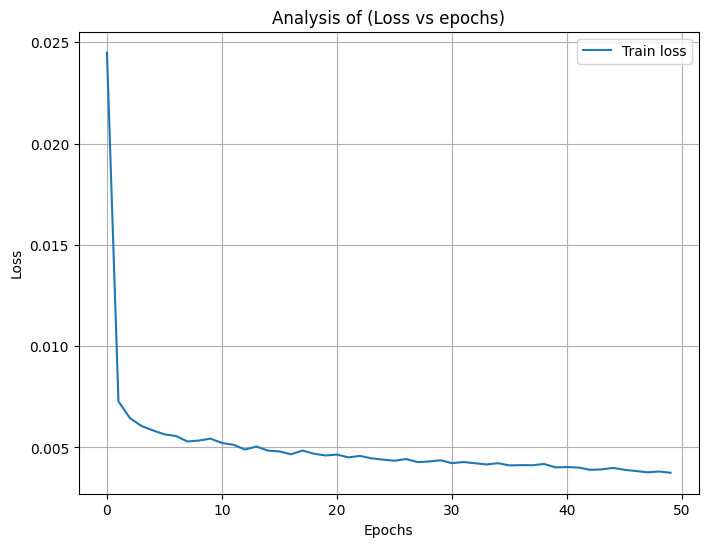

In [30]:
l = history.history['loss']
plt.figure(figsize=(8, 6))
plt.plot(l,label = "Train loss")

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Analysis of (Loss vs epochs)')
plt.legend()
plt.grid(True)